# Supplement Sales Search-Agent Forecasting

This notebook is a separate search-enabled for the supplement-sales agent. It follows the implementation and guide workflow: register only cutoff-visible data, inspect the exact prompt, attach a bounded cutoff-aware search sub-agent, and score one historical holdout.

Search is enabled in the agent configuration, but live calls remain guarded by `RUN_AGENT = False`. External context is appropriate for questions involving regulation, competitor pricing, supply disruption, or broad consumer demand; it is not a substitute for the sales history.

In [11]:
import json
import warnings
from pathlib import Path
from typing import Any, Callable

import numpy as np
import pandas as pd
from aieng.forecasting.data import DataService, SeriesMetadata
from aieng.forecasting.data.features import StaticFrameAdapter, canonical_three_col
from aieng.forecasting.evaluation.prediction import STANDARD_QUANTILES
from aieng.forecasting.evaluation.task import ForecastingTask
from aieng.forecasting.methods.agentic import AgentPredictor, ContinuousAgentForecastOutput
from aieng.forecasting.methods.agentic.agent_factory import AgentConfig, CodeExecutionConfig, ContextRetrievalConfig
from aieng.forecasting.models import LITE_MODEL, ADVANCED_MODEL
from dotenv import load_dotenv
from IPython.display import display
from pydantic import BaseModel

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 30)
pd.set_option("display.float_format", lambda value: f"{value:,.3f}")

## 1. Configure the historical origin

In [12]:
DATA_PATH = Path("Supplement_Sales_Weekly_Expanded.csv")
if not DATA_PATH.exists():
    DATA_PATH = Path("implementations/supplement_sales/Supplement_Sales_Weekly_Expanded.csv")

PRODUCT_NAME = "Whey Protein"
TRAIN_END_DATE = pd.Timestamp("2024-12-30")
HORIZON_WEEKS = 4
HISTORY_WEEKS = 52
AGENT_MODEL = LITE_MODEL
# AGENT_MODEL = ADVANCED_MODEL  # higher capability and cost
RUN_AGENT = True  # set True only after reviewing the prompt and confirming proxy credentials

DATE_COL = "Date"
PRODUCT_COL = "Product Name"
TARGET_COL = "Units Sold"
NUMERIC_CONTEXT = ["Price", "Revenue", "Discount", "Units Returned"]

ROOT = Path.cwd().resolve()
load_dotenv(ROOT / ".env", override=False)
sales = pd.read_csv(DATA_PATH, parse_dates=[DATE_COL])
product_data = sales.loc[sales[PRODUCT_COL] == PRODUCT_NAME].sort_values(DATE_COL).set_index(DATE_COL)
available_dates = pd.DatetimeIndex(sales[DATE_COL].drop_duplicates().sort_values())
if TRAIN_END_DATE not in available_dates or len(available_dates[available_dates > TRAIN_END_DATE]) < HORIZON_WEEKS:
    raise ValueError("The cutoff must be a dataset date with enough future observations.")
print(f"Product: {PRODUCT_NAME} | cutoff: {TRAIN_END_DATE.date()} | search enabled | RUN_AGENT={RUN_AGENT}")
display(product_data.tail())

Product: Whey Protein | cutoff: 2024-12-30 | search enabled | RUN_AGENT=True


,Product Name,Category,Units Sold,Price,Revenue,Discount,Units Returned,Location,Platform
Date,,,,,,,,,
2025-03-03,Whey Protein,Protein,160,27.080,"4,332.800",0.250,3,Canada,iHerb
2025-03-10,Whey Protein,Protein,140,24.030,"3,364.200",0.100,2,UK,Amazon
2025-03-17,Whey Protein,Protein,166,10.070,"1,671.620",0.090,3,Canada,iHerb
2025-03-24,Whey Protein,Protein,158,18.500,"2,923.000",0.020,0,UK,Amazon
2025-03-31,Whey Protein,Protein,148,15.170,"2,245.160",0.070,1,UK,Amazon


In [13]:
SERIES_ID = f"supplement_sales_{PRODUCT_NAME.lower().replace(' ', '_')}"
series_frame = product_data[[TARGET_COL]].reset_index().rename(columns={DATE_COL: "timestamp", TARGET_COL: "value"})
series_frame["released_at"] = series_frame["timestamp"]
service = DataService()
service.register(
    SERIES_ID,
    StaticFrameAdapter(canonical_three_col(series_frame)),
    SeriesMetadata(series_id=SERIES_ID, description=f"Weekly units sold for {PRODUCT_NAME}", source=str(DATA_PATH), units="units sold", frequency="W-MON"),
)
task = ForecastingTask(
    task_id=f"{SERIES_ID}_search_forecast",
    target_series_id=SERIES_ID,
    horizons=list(range(1, HORIZON_WEEKS + 1)),
    frequency="W-MON",
    description=f"Forecast weekly units sold for {PRODUCT_NAME} with cutoff-aware external context.",
)
context = service.context(as_of=TRAIN_END_DATE)
visible = context.get_series(SERIES_ID)
assert pd.Timestamp(visible["timestamp"].max()) == TRAIN_END_DATE
print(f"Visible rows: {len(visible)} | latest visible date: {visible['timestamp'].max().date()}")

Visible rows: 261 | latest visible date: 2024-12-30


## 2. Build the cutoff-safe search agent

In [14]:
class SearchPromptBuilder(BaseModel):
    history_weeks: int = HISTORY_WEEKS
    model_config = {"extra": "forbid"}

    def __call__(self, *, task: ForecastingTask, context) -> str:
        target = context.get_series(task.target_series_id).tail(self.history_weeks)
        cutoff = pd.Timestamp(context.as_of)
        rows = product_data.loc[product_data.index <= cutoff].tail(self.history_weeks)
        latest = rows.iloc[-1]
        payload: dict[str, Any] = {
            "task": task.task_id,
            "product_name": PRODUCT_NAME,
            "category": str(latest["Category"]),
            "as_of": str(cutoff.date()),
            "horizons_weeks": list(task.horizons),
            "standard_quantiles": list(STANDARD_QUANTILES),
            "target_summary": {
                "last_units_sold": float(target["value"].iloc[-1]),
                "last_date": str(pd.Timestamp(target["timestamp"].iloc[-1]).date()),
                "mean_units_sold": float(target["value"].mean()),
                "recent_mean_12": float(target["value"].tail(12).mean()),
                "recent_std_12": float(target["value"].tail(12).std() or 0.0),
            },
            "recent_history_csv": rows.reset_index()[[DATE_COL, TARGET_COL, *NUMERIC_CONTEXT]].to_csv(index=False, float_format="%.4f"),
            "external_context_scope": "Search may cover dated regulation, competitor, supply, or consumer-demand drivers relevant before as_of.",
            "context_note": "Use only observations and external events on or before as_of. Future prices, discounts, promotions, revenue, and returns are unknown.",
        }
        return json.dumps(payload, indent=2)

class ForecastPromptWrapper:
    def __init__(self, inner: Callable[..., str]):
        self.inner = inner
        self.schema = ContinuousAgentForecastOutput.prompt_schema_json()

    def __call__(self, *, task: ForecastingTask, context) -> str:
        payload = json.loads(self.inner(task=task, context=context))
        payload["instructions"] = (
            "Produce exactly one non-negative probabilistic forecast per horizon. Use the exact standard_quantiles, make them non-decreasing, set point_forecast to the 0.50 quantile, widen uncertainty with horizon, and state which search evidence matters. Return output_schema through set_model_response."
        )
        payload["output_schema"] = self.schema
        return json.dumps(payload, indent=2)

SEARCH_INSTRUCTION = (
    "You are a cutoff-aware supplement-retail intelligence specialist. Return a concise 3-5 paragraph brief grounded only in retrieved results. Prioritize dated regulatory or safety changes, competitor pricing or promotions, supply disruptions, and broad consumer-demand signals that could affect the configured product. Never report events after the cutoff; judge recency from the substance of each result, discard uncertain claims, and say when evidence is insufficient."
)
config = AgentConfig(
    name="supplement_sales_search_agent",
    model=AGENT_MODEL,
    instruction="You are a careful supplement-retail demand analyst. Combine the cutoff-safe sales history with relevant, dated external evidence. Do not invent causal effects or future covariates, and make uncertainty increase with horizon.",
    context_retrieval=ContextRetrievalConfig(enabled=True, instruction=SEARCH_INSTRUCTION),
    code_execution=CodeExecutionConfig(enabled=False),
)
prompt_builder = ForecastPromptWrapper(SearchPromptBuilder())
print("Agent:", config.name)
print("Search enabled:", config.context_retrieval.enabled)
print("Search model:", config.context_retrieval.search_model)

Agent: supplement_sales_search_agent
Search enabled: True
Search model: gemini-3.1-flash-lite-preview


## 3. Inspect before spending tokens

In [15]:
prompt_preview = prompt_builder(task=task, context=context)
prompt_path = Path("supplement_sales_search_prompt_preview.txt").resolve()
prompt_path.write_text(prompt_preview, encoding="utf-8")
assert "2025" not in prompt_preview
print(f"Saved prompt preview: {prompt_path}")
print(prompt_preview[:1800])

Saved prompt preview: /home/coder/agentic-forecasting/implementations/supplement_sales/supplement_sales_search_prompt_preview.txt
{
  "task": "supplement_sales_whey_protein_search_forecast",
  "product_name": "Whey Protein",
  "category": "Protein",
  "as_of": "2024-12-30",
  "horizons_weeks": [
    1,
    2,
    3,
    4
  ],
  "standard_quantiles": [
    0.05,
    0.1,
    0.2,
    0.3,
    0.4,
    0.5,
    0.6,
    0.7,
    0.8,
    0.9,
    0.95
  ],
  "target_summary": {
    "last_units_sold": 131.0,
    "last_date": "2024-12-30",
    "mean_units_sold": 150.67307692307693,
    "recent_mean_12": 153.66666666666666,
    "recent_std_12": 10.79000659982386
  },
  "recent_history_csv": "Date,Units Sold,Price,Revenue,Discount,Units Returned\n2024-01-08,149,52.3100,7794.1900,0.1100,2\n2024-01-15,148,53.4700,7913.5600,0.1200,4\n2024-01-22,158,30.6800,4847.4400,0.0900,2\n2024-01-29,149,23.0600,3435.9400,0.0800,3\n2024-02-05,144,38.9800,5613.1200,0.1800,0\n2024-02-12,144,34.1000,4910.4000,

## 4. Run and score one search-enabled forecast

In [16]:
agent_predictions = []
if RUN_AGENT:
    predictor = AgentPredictor(agent_config=config, prompt_builder=prompt_builder, output_schema=ContinuousAgentForecastOutput)
    agent_predictions = predictor.predict(task, context)
    for horizon, prediction in zip(task.horizons, agent_predictions, strict=True):
        forecast = prediction.payload
        print(f"h={horizon} | point={forecast.point_forecast:.2f} | P05={forecast.quantiles[0.05]:.2f} | P95={forecast.quantiles[0.95]:.2f}")
else:
    print("RUN_AGENT is False: prompt inspection completed without a live search or model call.")

h=1 | point=155.00 | P05=138.00 | P95=178.00
h=2 | point=158.00 | P05=135.00 | P95=184.00
h=3 | point=160.00 | P05=132.00 | P95=190.00
h=4 | point=157.00 | P05=128.00 | P95=193.00


In [17]:
search_audit = []
for horizon, prediction in zip(task.horizons, agent_predictions, strict=True):
    metadata = dict(prediction.metadata)
    search_audit.append(
        {
            "horizon": horizon,
            "forecast_date": str(prediction.forecast_date),
            "rationale": metadata.get("horizon_rationale") or metadata.get("rationale", ""),
            "langfuse_trace_url": metadata.get("langfuse_trace_url"),
            "langfuse_trace_id": metadata.get("langfuse_trace_id"),
        }
    )

search_audit_path = Path("supplement_sales_search_audit.json").resolve()
search_audit_path.write_text(json.dumps(search_audit, indent=2), encoding="utf-8")
display(pd.DataFrame(search_audit))
print(f"Search audit written to: {search_audit_path}")
print("Open each Langfuse trace and inspect the search_web.google_search and search_web.leakage_verifier spans for the search process and sources.")

,horizon,forecast_date,rationale,langfuse_trace_url,langfuse_trace_id
0,1,2025-01-06 00:00:00,Anticipating the seasonal 'New Year's resoluti...,https://us.cloud.langfuse.com/project/cmqqnhfj...,6b43a3ecef1e34f6c62e9f177f1bab01
1,2,2025-01-13 00:00:00,Continuing to reflect the peak seasonality of ...,https://us.cloud.langfuse.com/project/cmqqnhfj...,6b43a3ecef1e34f6c62e9f177f1bab01
2,3,2025-01-20 00:00:00,Maintaining a robust forecast as the January f...,https://us.cloud.langfuse.com/project/cmqqnhfj...,6b43a3ecef1e34f6c62e9f177f1bab01
3,4,2025-01-27 00:00:00,Expectation of a slight stabilization as the i...,https://us.cloud.langfuse.com/project/cmqqnhfj...,6b43a3ecef1e34f6c62e9f177f1bab01


Search audit written to: /home/coder/agentic-forecasting/implementations/supplement_sales/supplement_sales_search_audit.json
Open each Langfuse trace and inspect the search_web.google_search and search_web.leakage_verifier spans for the search process and sources.


In [18]:
future_dates = available_dates[available_dates > TRAIN_END_DATE][:HORIZON_WEEKS]
actual = product_data.loc[future_dates, TARGET_COL].astype(float).to_numpy()
rows = []
for prediction, actual_value, forecast_date in zip(agent_predictions, actual, future_dates, strict=True):
    forecast = prediction.payload
    rows.append({"Date": forecast_date, "Actual": actual_value, "Point forecast": float(forecast.point_forecast), "P05": float(forecast.quantiles[0.05]), "P95": float(forecast.quantiles[0.95])})
if rows:
    scored = pd.DataFrame(rows).set_index("Date")
    scored["Absolute error"] = (scored["Actual"] - scored["Point forecast"]).abs()
    scored["Covered"] = scored["Actual"].between(scored["P05"], scored["P95"])
    display(scored)
    print({"MAE": round(float(scored["Absolute error"].mean()), 3), "P05-P95 coverage": round(float(scored["Covered"].mean()), 3)})
else:
    print("No score yet. Set RUN_AGENT=True after reviewing the prompt.")

,Actual,Point forecast,P05,P95,Absolute error,Covered
Date,,,,,,
2025-01-06,148.000,155.000,138.000,178.000,7.000,True
2025-01-13,138.000,158.000,135.000,184.000,20.000,True
2025-01-20,155.000,160.000,132.000,190.000,5.000,True
2025-01-27,170.000,157.000,128.000,193.000,13.000,True


{'MAE': 11.25, 'P05-P95 coverage': 1.0}


In [19]:
BASELINE_HOLDOUT_RESULTS = pd.DataFrame(
    [
        {"Model": "Prophet", "MAE": 8.184, "RMSE": 10.070, "MAPE": 5.234, "sMAPE": 5.261},
        {"Model": "AutoARIMA", "MAE": 9.586, "RMSE": 11.988, "MAPE": 6.015, "sMAPE": 6.178},
        {"Model": "ARIMA", "MAE": 9.705, "RMSE": 11.838, "MAPE": 6.130, "sMAPE": 6.257},
        {"Model": "LightGBM", "MAE": 10.809, "RMSE": 13.048, "MAPE": 6.809, "sMAPE": 7.002},
        {"Model": "Last Value", "MAE": 23.846, "RMSE": 26.315, "MAPE": 14.969, "sMAPE": 16.410},
    ]
)

comparison = BASELINE_HOLDOUT_RESULTS.copy()
if not scored.empty:
    actual_values = scored["Actual"].to_numpy(dtype=float)
    predicted_values = scored["Point forecast"].to_numpy(dtype=float)
    denominator = np.maximum((np.abs(actual_values) + np.abs(predicted_values)) / 2, 1e-8)
    comparison.loc[len(comparison)] = {
        "Model": "Search agent",
        "MAE": float(np.mean(np.abs(actual_values - predicted_values))),
        "RMSE": float(np.sqrt(np.mean((actual_values - predicted_values) ** 2))),
        "MAPE": float(np.mean(np.abs((actual_values - predicted_values) / np.maximum(np.abs(actual_values), 1e-8))) * 100),
        "sMAPE": float(np.mean(np.abs(actual_values - predicted_values) / denominator) * 100),
    }

display(comparison.sort_values("MAE").set_index("Model").style.format("{:.3f}"))

,MAE,RMSE,MAPE,sMAPE
Model,,,,
Prophet,8.184,10.070,5.234,5.261
AutoARIMA,9.586,11.988,6.015,6.178
ARIMA,9.705,11.838,6.130,6.257
LightGBM,10.809,13.048,6.809,7.002
Search agent,11.250,12.679,7.524,7.315
Last Value,23.846,26.315,14.969,16.410


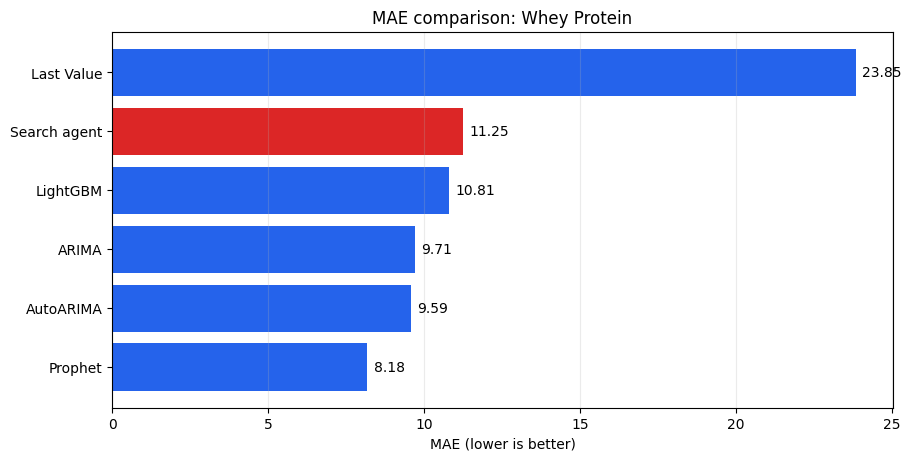

In [20]:
import matplotlib.pyplot as plt

mae_comparison = comparison.sort_values("MAE")
colors = ["#dc2626" if model == "Search agent" else "#2563eb" for model in mae_comparison["Model"]]

fig, ax = plt.subplots(figsize=(9, 4.5), layout="constrained")
ax.barh(mae_comparison["Model"], mae_comparison["MAE"], color=colors)
ax.set_title(f"MAE comparison: {PRODUCT_NAME}")
ax.set_xlabel("MAE (lower is better)")
ax.grid(axis="x", alpha=0.25)
for index, value in enumerate(mae_comparison["MAE"]):
    ax.text(value + 0.2, index, f"{value:.2f}", va="center")
plt.show()

## Notes

- This is an A/B strategy, not a replacement for `03_agent_analyst_backtest.ipynb`; compare search and no-search on the same rolling origins before drawing conclusions.
- The agent name is intentionally distinct so search results do not overwrite no-search cache artifacts.
- The search tool is cutoff-aware, but inspect a trace and the prompt before trusting a result. External evidence should explain a demand driver, not override observed sales without justification.